
# Tutorial Outline: Spectral Embedding Methods

## 1. Introduction

* **Motivation:**

  * Mass spectra are sparse, high-dimensional signals.
  * To analyze them efficiently, we need to transform spectra into lower-dimensional, machine-readable embeddings.
  
* **Learning Goals:**

  * Understand X approaches to spectral embedding.
  * See how dimensionality reduction and embeddings enable clustering, visualization, and downstream ML tasks.

Below, you'll find some code to get you started. (Code was mostly taken from [Lesson 4](https://colab.research.google.com/drive/13WEV58HpkY7f0kFi2BA5ia5p0XZCL3Cq?authuser=1#scrollTo=FYgmwfThBQJJ))

In the context of this tutorial, the most useful end result from these functions is the MS2 spectrum object, as well as to serve as examples for how to use pyteomics

In [152]:
%%capture
%pip install pyteomics
%pip install plotly==5.18.0
%pip install pandas
%pip install spectrum_utils==0.4.2
%pip install scikit-learn
%pip install rapidhash


In [153]:
# @title Run this cell to download parent Google drive contents
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml, auxiliary
import plotly.io as pio
import plotly.tools as tls
import plotly.graph_objects as go
import pandas as pd
import random
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from matplotlib import pyplot as plt

In [154]:
# @title Run this cell to create our amino acid dictionary (from Lesson 1).
aa_mass = {'A': 71.037114, 'R':156.101111 , 'N': 114.042927,
           'D': 115.026943, 'C': 103.009185, 'E': 129.042593,
           'Q' : 128.058578, 'G': 57.021464, 'H': 137.058912,
           'I': 113.084064, 'L': 113.084064, 'K': 128.094963,
           'M' : 131.040485, 'F':  147.068414, 'P':  97.052764,
           'S': 87.032028, 'T': 101.047679, 'U': 150.95363,
           'W': 186.079313, 'Y': 163.06332, 'V': 99.068414}

In [155]:
# @title Run this cell to declare a function that creates a b-/y-ion ladder for a peptide.

# This will make a b/y ion ladder for any given peptide and put it in a dataframe
def make_ion_ladder(peptide, aa_mass):
    b_ions = {}
    y_ions = {}

    mass_Hydrogen = 1.0078
    mass_Oxygen = 15.994915
    proton_mass = 1.007

    '''
    Note: In the following functions, if you look closely to the calculations,
    you will see some additions of protons that are different to what we did in
    lesson 1 & 2. This is because instead of enzymatically digesting a protein,
    we are violently fragmenting the peptides milliseconds before measuring them.
    The physics is a little more complicated, so don't worry too much about it.

    If you really want to know the chemistry/physics behind this, you can read
    about it in this paper: https://cse.sc.edu/~rose/790B/papers/dancik.pdf
    '''
    # Generate b-ions
    b_mass_current = 0
    b_ion = ''
    fragment = 0
    for aa in peptide:
        b_ion += aa
        if (b_ion != peptide):
          b_mass_current += aa_mass[aa]
          b_ions[b_ion] = b_mass_current + proton_mass # mass of the charge on fragment

    # Generate y-ions
    y_mass_current = mass_Hydrogen + mass_Oxygen #adds terminal OH
    y_mass_current += proton_mass
    y_ion = ''
    fragment = 0
    for aa in peptide[::-1]:
        y_ion += aa
        if (y_ion[::-1] != peptide):
          y_mass_current += aa_mass[aa]
          y_ions[y_ion[::-1]] = y_mass_current + proton_mass #mass of charge on fragment

    # Populate dataframe
    data = {
        'b#': [b+1 for b in range(len(peptide)-1)],
        'b_ion_m/z': [b_ions[b_key] for b_key in b_ions.keys()],
        'b_ion_sequence': [b_key for b_key in b_ions.keys()],
        'y_ion_sequence': [y_key for y_key in y_ions.keys()][::-1],
        'y_ion_m/z': [y_ions[y_key] for y_key in y_ions.keys()][::-1],
        'y#': [len(peptide)-i-1 for i in range(len(peptide)-1)]
    }

    # Format dataframe
    df = pd.DataFrame(data)
    # df = df.style.set_properties(
    #     subset=['b_ion_sequence'],
    #     **{'text-align': 'left'}
    # ).format({
    #     'b_ion_m/z': '{:,.2f}',
    #     'y_ion_m/z': '{:,.2f}'
    # }).set_table_styles([{
    #     'selector': 'thead th',
    #     'props': [('vertical-align', 'bottom'), ('text-align', 'left')]
    # }, {
    #     'selector': 'th.index_name',  # targeting the index name specifically
    #     'props': [('vertical-align', 'bottom')]
    # }])

    # print(df)
    return(df)

In [156]:
# @title Run this cell to declare a function that gets an MS2 spectrum object

def get_MS2_object(mzml_path, scan, peptide = None):
    su_spectrum = None
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            scanNumber = int(spectrum['id'].split('=')[-1])
            if scanNumber == scan:
                # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
                spectrum_id = spectrum['id']
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Process the spectrum
                su_spectrum = (su_spectrum.filter_intensity(0.05, 100)
                               .remove_precursor_peak(fragment_tol_mass=0.5, fragment_tol_mode='Da')
                               .scale_intensity('root'))
                break
    # Formatting
    if su_spectrum:
        fragment_tol_mass = 0.5
        fragment_tol_mode = 'Da'  ## for some reason, if I use 'ppm' it doesn't work

        # If given the peptide, spec_utils can annotate the peaks
        if peptide:
          su_spectrum = su_spectrum.annotate_proforma(peptide, fragment_tol_mass, fragment_tol_mode, ion_types='by', max_ion_charge=2)
    return su_spectrum

In [157]:
# @title Run this cell to declare a function that plots an MS2 spectrum.

def plot_MS2(ms2_spectrum):
    ax = sup.spectrum(ms2_spectrum)
    plotly_fig = tls.mpl_to_plotly(ax.figure)
    plotly_fig['layout']['plot_bgcolor'] = 'white'
    plotly_fig['layout']['xaxis']['showline'] = True
    plotly_fig['layout']['xaxis']['linecolor'] = 'black'
    plotly_fig['layout']['xaxis']['linewidth'] = 2
    plotly_fig['layout']['yaxis']['linecolor'] = 'black'
    plotly_fig['layout']['yaxis']['linewidth'] = 2
    plotly_fig.show()

In [158]:
# This function is defined above in Part 1 - take a look at the code up
#   there to see what it is doing
make_ion_ladder('VLDALDSIK', aa_mass)

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,100.075414,V,LDALDSIK,874.486898,8
1,2,213.159478,VL,DALDSIK,761.402834,7
2,3,328.186421,VLD,ALDSIK,646.375891,6
3,4,399.223535,VLDA,LDSIK,575.338777,5
4,5,512.307599,VLDAL,DSIK,462.254713,4
5,6,627.334542,VLDALD,SIK,347.227770,3
6,7,714.366570,VLDALDS,IK,260.195742,2
7,8,827.450634,VLDALDSI,K,147.111678,1


In [159]:
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML'
ms2_spectrum_unannotated = get_MS2_object(mzml_path, 5672)
plot_MS2(ms2_spectrum_unannotated)

In [160]:
ms2_spectrum_annotated = get_MS2_object(mzml_path, 5672, peptide = 'VLDALDSIK')
plot_MS2(ms2_spectrum_annotated)


## 2. Method 1: Spectral Hashing
### 2.1 The Context

* **Required Reading:** https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291.  
* **Open Modification Searching (OMS)** is a strategy for detecting proteoforms in MS that applies a wide m/z window to match modified spectra with their unmodified peptide counterparts, then infers potential post-translational modifications (PTMs) based on the resulting mass differences. "All possible modifications are implicitly considered."
* OMS is **inefficient** because the search window is significantly larger than the standard search window.
* The solution? Using only a limited number of modified spectra to compare to an unknown spectrum. Here lies the process of **spectral binning and hashing.**

### 2.2 Conceptual Introduction
* Spectra are naturally high-dimensional. Each m/z bin acts as a separate axis.
* To make clustering more efficient, we use spectral embedding to project spectra into lower-dimensional spaces while preserving their relationships.
* We’ll walk through an intuitive example of **clustering in 2D.** In practice, the embedding space can have hundreds of dimensions, but the same idea applies.
<br></br>
<img src="Clustering-1.jpeg" width="500" height="675">
<img src="Clustering-2.jpeg" width="500" height="675">

### 2.3 From Peaks to Vectors

* Represent a spectrum as a list of *m/z*–intensity pairs.
* Traditional binning: divide the *m/z* axis into bins and assign intensities.
* Limitation: When binning, you have to take a **continuous value** (m/z) and transform it to a **discrete value**. This presents two problems
  * Information is lost! Small differences in the m/z dimension can give very imporant information
  * The same peak can extend across multiple bins. Imagine a peak that is located precisely at 999.999 m/z. Depending on how well/poorly the instrument is calibrated, the same peak can be sorted into different bins
  * To demonstrate this, show how feature hashing fails to differentiate between TMT channels
    * Only fails if not small enough and hash matrix collides too often. 

### 2.4 Feature Hashing for Spectral Embedding

* Use **feature hashing** to map high-resolution bins into a fixed-length vector (e.g., 880 dimensions).
* Each *m/z* bin is hashed into one of the vector’s components, accumulating intensity.
* Benefits:

  * Compact vector representation.
  * Preserves similarity structure for clustering or approximate nearest neighbor (ANN) search.

![continuous-discrete-fig](continuous-discrete.png)


## 2.5 Similarity Preservation in Embeddings

* Feature hashing preserves **similarity relationships** between spectra.
* Two similar spectra will produce similar hash vectors (with high dot product similarity).
* Later, we'll demonstrate this by:
  * Computing similarity between spectra from the same peptide
  * Showing how similar peptides cluster together in embedding space

**Theoretical steps**

The paper simplifies feature hashing down to two main steps:

1. Convert the spectrum to a sparse vector
using small mass bins to tightly capture
fragment masses.
2. Hash the sparse, high-dimensional
vector to a lower- dimensional vector by using a hash
function to map the mass bins to a limited number of hash bins

![fig-1.png](https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif)

I explain what this means practically, line by line, in the code below.

In [161]:
# Quick note that spectra is plural, spectrum is singular.
# The getMS2 function takes in a parameter, scan, which chooses a single spectrum of ms2

spectrum_mz = ms2_spectrum_unannotated.mz
'''
Where spectrum_mz =
[129.10374451 147.11447144 185.16696167 186.17019653 213.16217041
 229.1210022  260.20001221 298.14343262 300.1590271  328.190979
 347.23321533 348.23629761 462.26141357 463.26467896 484.20996094
 575.34680176 646.3848877  647.38745117 743.4017334  761.41223145
 762.41516113 763.41802979 874.49749756 875.50030518]
'''
spectrum_int = ms2_spectrum_unannotated.intensity
'''
Where spectrum_int =
[2174.818  3145.84   9230.925  2883.7764 4380.564  2282.9873 3063.1228
 2072.459  3142.8696 2672.6929 5380.33   2240.3975 6059.931  2831.662
 2237.5989 3632.9626 4356.975  2494.9565 2366.8223 8133.1064 5098.785
 2226.6924 4098.929  2766.6738]d
'''
# Intensity and mz values are parallel arrays, which is more clearly visible via the common graphs above, as well as:
assert(len(spectrum_int) == len(spectrum_mz))

Speaking of which, take a look at the (un)annotated spectrum graphs, figure, and theoretical steps above again! Here are some corollaries we can find from them:
- This particular spectrum ranges from mz values from 0 through ~880.
- _Sparse Array_: An array of mostly zeroes, with a few values intermingled throughout the array
- Suppose we wanted to put these mz and intensity values into a sparse array
    - How can we represent both of these things in a single, non 2d array?
        - What if we had len(arr) = 880? And then we round down each mz value to the nearest integer? Then, we'd be able to represent an mz of, say, 129.10374451 in the 128th (0 based) index, and put its corresponding intensity (2174.818) in the 128th spot in the array of len 880.


Here are the numerical values:
```python
spectrum_mz =
[129.10374451 147.11447144 185.16696167 186.17019653 213.16217041
 229.1210022  260.20001221 298.14343262 300.1590271  328.190979
 347.23321533 348.23629761 462.26141357 463.26467896 484.20996094
 575.34680176 646.3848877  647.38745117 743.4017334  761.41223145
 762.41516113 763.41802979 874.49749756 875.50030518]


spectrum_int =
[2174.818  3145.84   9230.925  2883.7764 4380.564  2282.9873 3063.1228
 2072.459  3142.8696 2672.6929 5380.33   2240.3975 6059.931  2831.662
 2237.5989 3632.9626 4356.975  2494.9565 2366.8223 8133.1064 5098.785
 2226.6924 4098.929  2766.6738]
```

We'll rewrite this into our new array of length 880 as a numerical example.
*   In the 129th idx: 2174.818
*   In the 147th idx: 3145.84
*   In the 185th idx: 9230.925
*   And so on...

Indices that aren't mapped to anything are zeroed out.

In [162]:
# @title Run to see the Sparse Array Concept
# Sparse array concept
display(Latex(r'''
\begin{align}
\text{Here's an empty list: } &\quad [\ ] \\[0.5em]
\text{Here's a list with 880 zeroes filled in: } &\quad [0, 0, 0, \ldots, 0, 0] \\[0.5em]
\text{Indices: } &\quad 0, 1, 2, \ldots, 879, 880 \\[0.5em]
\text{Now, let's add a sample of such values at each index:} & \quad [0, \ldots, 2174.818, \ldots, 3145.84, \ldots,0] \\[0.5em]
\text{Indices: } &\quad [0, \ldots, 12910, \ldots, 14711, \ldots] 
\end{align}
'''))


display(Latex(r'''

\begin{align*}
\text{Lines 4 and 5 are what we'll simulate our map below to look like, just without any of the 0 values.}
\end{align*}'''))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Now, my intention is to give some motivation to why we want more than just 880 values, even though they all work just fine. 
- That is to say, the m/z at 129.4 and 128.5 (both idx=129 if we round to nearest int) _aren't_ colliding because such m/z values don't exist

But what if they were? 
Below, we've modified the get_MS2_object to get_all_MS2_objects in order to show the possibility that multiple m/z values. When we plot all 400 spectra in this mzML, let's see how many collisions LOOK like they're occuring:

In [163]:
def get_all_MS2_objects(mzml_path):
    ms2_spectra = []
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            # This finds the corresponding values in the .mzml file to create list of ms2 objs
            ms_level = spectrum.get('ms level', 0)  # Use 'ms level' not 'level'
            if ms_level == 2:
                spectrum_id = spectrum['id']  # Use spectrum['id'], not spectrum['ms level'][0]
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Process the spectrum
                processed_spectrum = (su_spectrum.filter_intensity(0.05, 100)
                                    .remove_precursor_peak(fragment_tol_mass=0.5, fragment_tol_mode='Da')
                                    .scale_intensity('root'))

                # Add processed spectrum to our list
                ms2_spectra.append(processed_spectrum)


    return ms2_spectra

In [164]:
def plot_multiple_MS2(x, y, title="Spectrum Plot", xlabel="m/z", ylabel="Intensity", figsize=(10, 6)):
    """
    Create a stem plot (like MS2 spectra) from x,y arrays using matplotlib.
    
    Parameters:
    x: array-like, x-coordinates (m/z values)
    y: array-like, y-coordinates (intensity values)
    title: str, plot title
    xlabel: str, x-axis label
    ylabel: str, y-axis label
    figsize: tuple, figure size (width, height)
    """
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the stem plot (vertical lines like MS2 spectra)
    markerline, stemlines, baseline = ax.stem(x, y, basefmt=" ")
    
    # Customize the stem plot appearance
    plt.setp(stemlines, 'linewidth', 1.2, 'color', 'black')
    plt.setp(markerline, 'markersize', 3, 'color', 'black')
    
    # Customize the plot to match plot_MS2 style
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Set background color to white and add borders like plot_MS2
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()

Total peaks from all spectra: 25099
m/z range: 84.05 to 1993.28


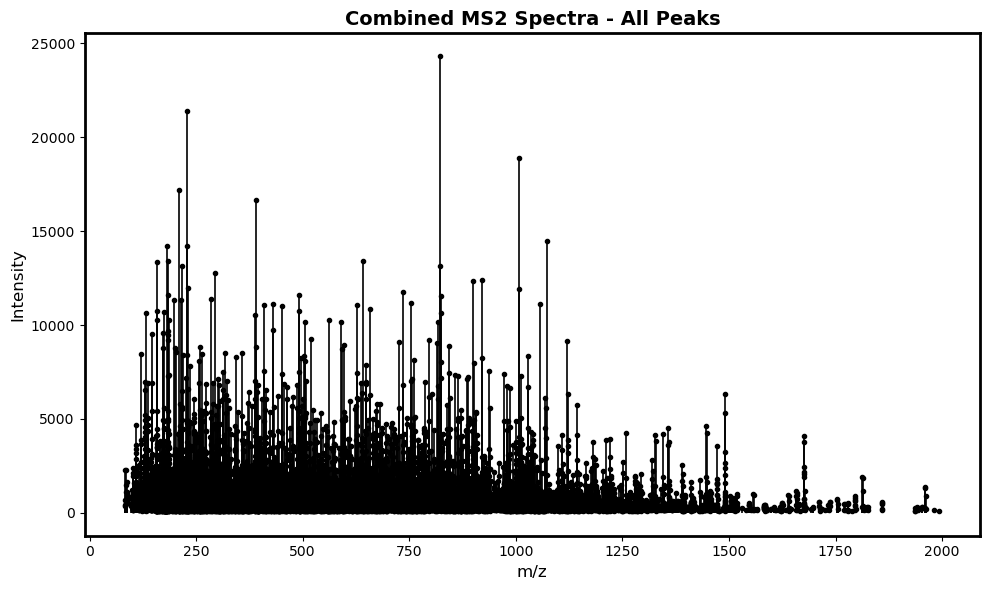

In [165]:
# Let's combine all m/z and intensity values from all spectra into single arrays
sum_mz = []
sum_int = []
for ms2 in get_all_MS2_objects(mzml_path):
    sum_mz.extend(ms2.mz)
    sum_int.extend(ms2.intensity)

print(f"Total peaks from all spectra: {len(sum_mz)}")
print(f"m/z range: {min(sum_mz):.2f} to {max(sum_mz):.2f}")

plot_multiple_MS2(sum_mz, sum_int, 
                  title="Combined MS2 Spectra - All Peaks", 
                  xlabel="m/z", 
                  ylabel="Intensity")

We've taken our mzml file, outputted every MS2 spectrum, and overlayed it in one graph.

There must be _hundreds_ of collisions happening between m/zs rounding down to the same integer.

In [166]:
def plot_multiple_MS2(x, y, title="Line Plot", xlabel="X-axis", ylabel="Y-axis", figsize=(10, 6)):
    """
    Create a line plot from x,y arrays using matplotlib.
    
    Parameters:
    x: array-like, x-coordinates
    y: array-like, y-coordinates  
    title: str, plot title
    xlabel: str, x-axis label
    ylabel: str, y-axis label
    figsize: tuple, figure size (width, height)
    """
    
    # Create the figure and axis
    plt.figure(figsize=figsize)
    
    # Create the line plot
    plt.plot(x, y, linewidth=1.5, color='blue')
    
    # Customize the plot to match plot_MS2 style
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    # Add grid for better readability
    plt.grid(True, alpha=0.3)
    
    # Set background color to white and add borders like plot_MS2
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(True)
    plt.gca().spines['right'].set_visible(True)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.gca().spines['top'].set_linewidth(2)
    plt.gca().spines['right'].set_linewidth(2)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()  # Only plot first 5 to avoid overhwelming output.


**Why use more precise m/z indices?**

If we had 200 unique m/z values ranging from 100–300 and rounded each to the nearest integer, we’d quickly run into overlaps. For example, every value between 128.5 ≤ m/z < 129.5 would collapse into the same index: 129. That means different peaks could get “bucketed” together, and we'd lose resolution.

To avoid this, we can create finer-grained buckets:
* Nearest 1.0 → array length = max(mz)
* Nearest 0.1 → array length ≈ max(mz) * 10
* Nearest 0.001 → array length ≈ max(mz) * 1000

So if max(mz) = 880, then:
* 0.1 precision → 8,800 buckets
* 0.001 precision → 880,000 buckets

Increased precision = bigger arrays. At very high precision (like 880k slots), things become computationally expensive and impractical, even if they are technically more accurate. We'll try a slightly different approach, one that better follows the actual paper.

In [167]:
# @title Open this cell for step 1
import math


WIDTH_OF_BIN = 0.01
LENGTH = int(max(spectrum_mz) // WIDTH_OF_BIN +1) # integer rounding up one.
print(f"We have to fit our m/zs into bins by rounding them to the nearest {WIDTH_OF_BIN}")
print(f"The length of our (simulated) array is {LENGTH}")

def to_idx(num): # where num = mz val
    """
    Convert m/z value to a sparse vector index.

    This implements STEP 1 from the theoretical framework:
    "Convert the spectrum to a sparse vector using small mass bins"

    We divide m/z by 0.01 to create bins of 0.01 Da width.
    For example: 129.103 m/z → index 12910
    This creates fine-grained bins that preserve mass accuracy.
    """
    return int(num // WIDTH_OF_BIN) # round to third decimal and return the result. int since these will be 0 based indices


# IMPORTANT BELOW
# Create the sparse representation: map from m/z indices to intensities
# This is our "sparse vector" - instead of a huge array with mostly zeros,
# we only store the non-zero entries in a dictionary
map = {}
# Populate the sparse vector with our spectrum data
for i, mz in enumerate(spectrum_mz):
    # Convert each m/z to its corresponding index and store the intensity
    map[to_idx(mz)] = spectrum_int[i]

# Pretty print the map dictionary
print("The map dictionary looks like:")
print(f"m/z bin: intensity")
for idx, intensity in sorted(map.items()):
    print(f"  {idx}: {intensity:.3f} ")
print("Where we only keep the nonzero values from our \"simulated array\"")
print(spectrum_mz[0], "rounds to",to_idx(spectrum_mz[0]))
# outputs: 129.10374450683594 12910

# Verify our expected index correctly matches our intensity (see mz and intensity arrays).
expectedValue = map[to_idx(spectrum_mz[0])]
assert math.isclose(expectedValue, 2174.818, abs_tol=0.001) # This is best practice for comparing floating pts

# Example of what our sparse vector looks like conceptually: 2174.818
# sparse_index → intensity
# 12910 → 2174.818  (from m/z 129.104)
# 14711 → 3145.84   (from m/z 147.114)
# 18516 → 9230.925  (from m/z 185.167)
# ...
#
# This avoids creating a massive array of ~880,000 zeros with just ~24 non-zero values!

We have to fit our m/zs into bins by rounding them to the nearest 0.01
The length of our (simulated) array is 87551
The map dictionary looks like:
m/z bin: intensity
  12910: 2174.818 
  14711: 3145.840 
  18516: 9230.925 
  18617: 2883.776 
  21316: 4380.564 
  22912: 2282.987 
  26020: 3063.123 
  29814: 2072.459 
  30015: 3142.870 
  32819: 2672.693 
  34723: 5380.330 
  34823: 2240.397 
  46226: 6059.931 
  46326: 2831.662 
  48420: 2237.599 
  57534: 3632.963 
  64638: 4356.975 
  64738: 2494.957 
  74340: 2366.822 
  76141: 8133.106 
  76241: 5098.785 
  76341: 2226.692 
  87449: 4098.929 
  87550: 2766.674 
Where we only keep the nonzero values from our "simulated array"
129.10374450683594 rounds to 12910


In [168]:
# @title Open this cell for Step 2
# STEP 2 from theoretical framework: Hash the high-dimensional sparse vector
# to a lower-dimensional vector using a hash function

hash_buckets = 400  # Our target dimensionality (much smaller than ~880k sparse indices)

def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 399)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')

    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % hash_buckets

# Initialize our final feature 
# This is our compact, fixed-size representation of the spectrum
hash_matrix = [0] * hash_buckets  # Start with all zeros

# The final step: populate the hash buckets with intensities
# Multiple sparse indices may hash to the same bucket (collisions)
# We handle collisions by ADDING intensities (preserving total signal)

for sparse_idx, intensity in map.items(): # see how map allows us to not have to look through every bin?
    # Get the hash bucket for this sparse index
    bucket_idx = hasher(sparse_idx)

    # Add the intensity to the bucket (handles collisions by summation)
    hash_matrix[bucket_idx] += intensity

print("Final spectral hash vector:")

end = "["
for hashedVals in hash_matrix:
    if hashedVals != 0:
        end += f"{hashedVals:.2f},"
    if hashedVals ==0:
        end += f"{hashedVals},"
end = end[:len(end)-1]
print(end,end="]\n")
print("Non-zero buckets:", sum(1 for x in hash_matrix if x > 0), f"out of {hash_buckets} buckets" )

Final spectral hash vector:
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2831.66,0,0,0,0,0,0,0,0,0,0,3142.87,0,0,0,5380.33,0,3632.96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6059.93,0,0,0,0,0,2072.46,0,0,0,0,0,0,0,0,0,0,0,0,0,4098.93,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2883.78,0,2282.99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4356.98,0,0,0,0,0,0,0,0,0,0,0,2366.82,0,0,0,0,0,0,0,9230.92,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5098.79,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2174.82,0,0,0,0,0,0,2240.40,0,0,0,0,2226.69,0,0,0,0,0,0,0,0,0,2494.96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4380.56,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3063.12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3145.84,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2672.69,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2766.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8133.11,0,0,0,2237.60,0]
Non-zero buckets: 24 out o

**SUMMARY** of the spectral hashing process:
1. Started with: 24 (m/z, intensity) pairs
2. Essentially to: ~88,000 possible sparse indices, only 24 actually used
3. Hashed down to: 400 compact feature dimensions
4. Result: Fixed-size vector that preserves spectral similarity for ML/clustering

What does it mean to **preserve similarity?**

Maintaining the relative closeness between spectra after hashing, so you can perform clustering or nearest neighbor search without needing the full 88,000-dimensional sparse vector.

Two vectors $\vec{x}$ and $\vec{z}$ are more similar than $\vec{x}$ and $\vec{y}$ if their dot product, is greater than the latter.

$\vec{x} \cdot \vec{z} > \vec{x} \cdot \vec{y} $



## Spectral Hashing Example, Start to Finish

### Set-Up/Background

Below is the ion ladder for the peptide: AVVQDPALKPLALVYGEATSR.

In [169]:
make_ion_ladder('AVVQDPALKPLALVYGEATSR', aa_mass)

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,72.044114,A,VVQDPALKPLALVYGEATSR,2127.179698,20
1,2,171.112528,AV,VQDPALKPLALVYGEATSR,2028.111284,19
2,3,270.180942,AVV,QDPALKPLALVYGEATSR,1929.042870,18
3,4,398.239520,AVVQ,DPALKPLALVYGEATSR,1800.984292,17
4,5,513.266463,AVVQD,PALKPLALVYGEATSR,1685.957349,16
5,6,610.319227,AVVQDP,ALKPLALVYGEATSR,1588.904585,15
6,7,681.356341,AVVQDPA,LKPLALVYGEATSR,1517.867471,14
7,8,794.440405,AVVQDPAL,KPLALVYGEATSR,1404.783407,13
8,9,922.535368,AVVQDPALK,PLALVYGEATSR,1276.688444,12
9,10,1019.588132,AVVQDPALKP,LALVYGEATSR,1179.635680,11


Let's look at how this ion ladder can be plotted as a "spectrum." The purpose of this is to visualize the spread of m/z values. The intensity values here are meaningless.

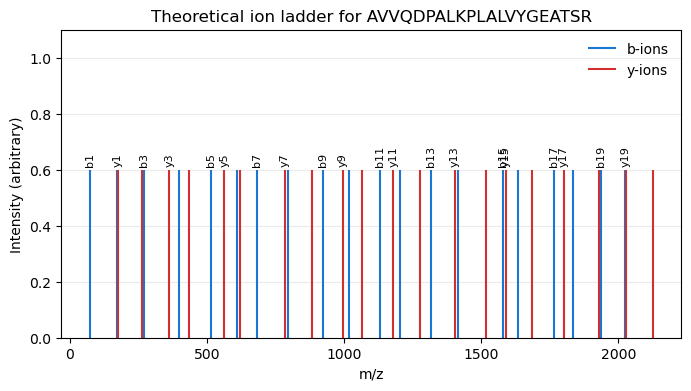

In [ ]:
b_mz = [
    72.044114, 171.112528, 270.180942, 398.239520, 513.266463,
    610.319227, 681.356341, 794.440405, 922.535368, 1019.588132,
    1132.672196, 1203.709310, 1316.793374, 1415.861788, 1578.925108,
    1635.946572, 1764.989165, 1836.026279, 1937.073958, 2024.105986
]

y_mz = [
    2127.179698, 2028.111284, 1929.042870, 1800.984292, 1685.957349,
    1588.904585, 1517.867471, 1404.783407, 1276.688444, 1179.635680,
    1066.551616, 995.514502, 882.430438, 783.362024, 620.298704,
    563.277240, 434.234647, 363.197533, 262.149854, 175.117826
]

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

# Equal heights (e.g., 1.0)
height = 0.6
ax.vlines(b_mz, 0, height, colors='#1976D2', linewidth=1.5, label='b-ions')
ax.vlines(y_mz, 0, height, colors='#D32F2F',  linewidth=1.5, label='y-ions')

ax.set_ylim(0, 1.1)
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity (arbitrary)")
ax.set_title("Theoretical ion ladder for AVVQDPALKPLALVYGEATSR")
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.25)

# b labels: b1, b3, b5, ...
for i, x in enumerate(b_mz, start=1):
    if i % 2 == 1:
        ax.text(x, height*1.02, f"b{i}", rotation=90, ha="center", va="bottom", fontsize=8)

# y_mz is descending (y20..y1). Convert to ion number j = y#
n_y = len(y_mz)
for i, x in enumerate(y_mz, start=1):
    j = n_y - i + 1   # y ion number at this m/z
    if j % 2 == 1:    # y1, y3, y5, ...
        ax.text(x, height*1.02, f"y{j}", rotation=90, ha="center", va="bottom", fontsize=8)

plt.show()

Now that we've visualized this theoretical ion ladder as a "spectrum," let's plot a real spectrum and use the ion ladder to annotate it. The spectrum plotted below is the unmodified AVVQDPALKPLALVYGEATSR peptide.

In [183]:
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'
plot_MS2(get_MS2_object(mzml_path, 9970, peptide = 'AVVQDPALKPLALVYGEATSR')) # Scan 9970 is the unmodified spectrum for sequence AVVQDPALKPLALVYGEATSR

Although there is inevitable noise that deviates from the theoretical ion ladder, this spectrum overall aligns really well with the ladder. In other words, **a significant proportion of this spectrum's total intensity is accounted for by the theoretical ion ladder.** Let's now look at a modified version of AVVQDPALKPLALVYGEATSR.

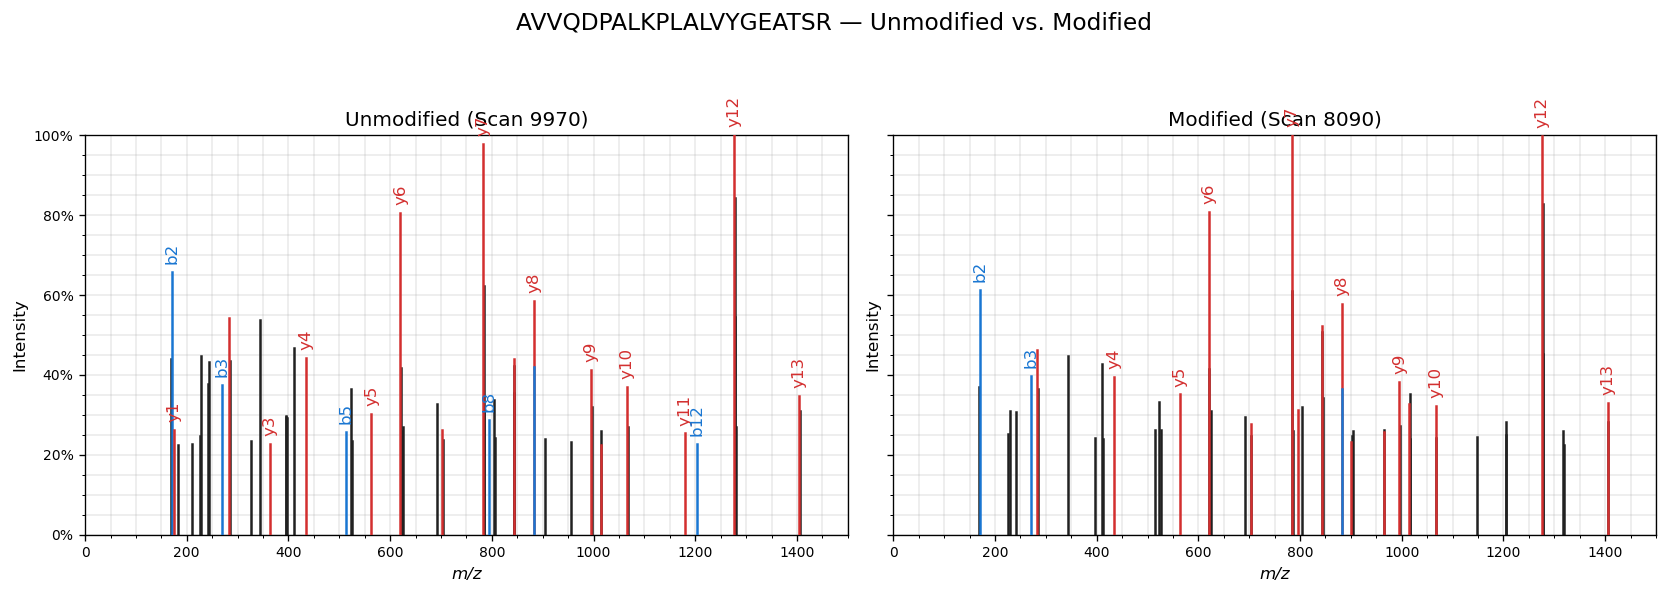

In [195]:

seq = 'AVVQDPALKPLALVYGEATSR'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 9970, peptide=seq)
spec_right = get_MS2_object(mzml_path, 8090, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = unmodified = scan 9970
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 9970)")

# Right panel = modified = scan 8090
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8090)")

fig.suptitle("AVVQDPALKPLALVYGEATSR — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

We can repeat that process using an unmodified and modified spectrum from each of the 2 other peptides in our mzml file: IITHPNFNGNTLDNDIMLIK and RMVNNGHSFNVEYDDSQDK.

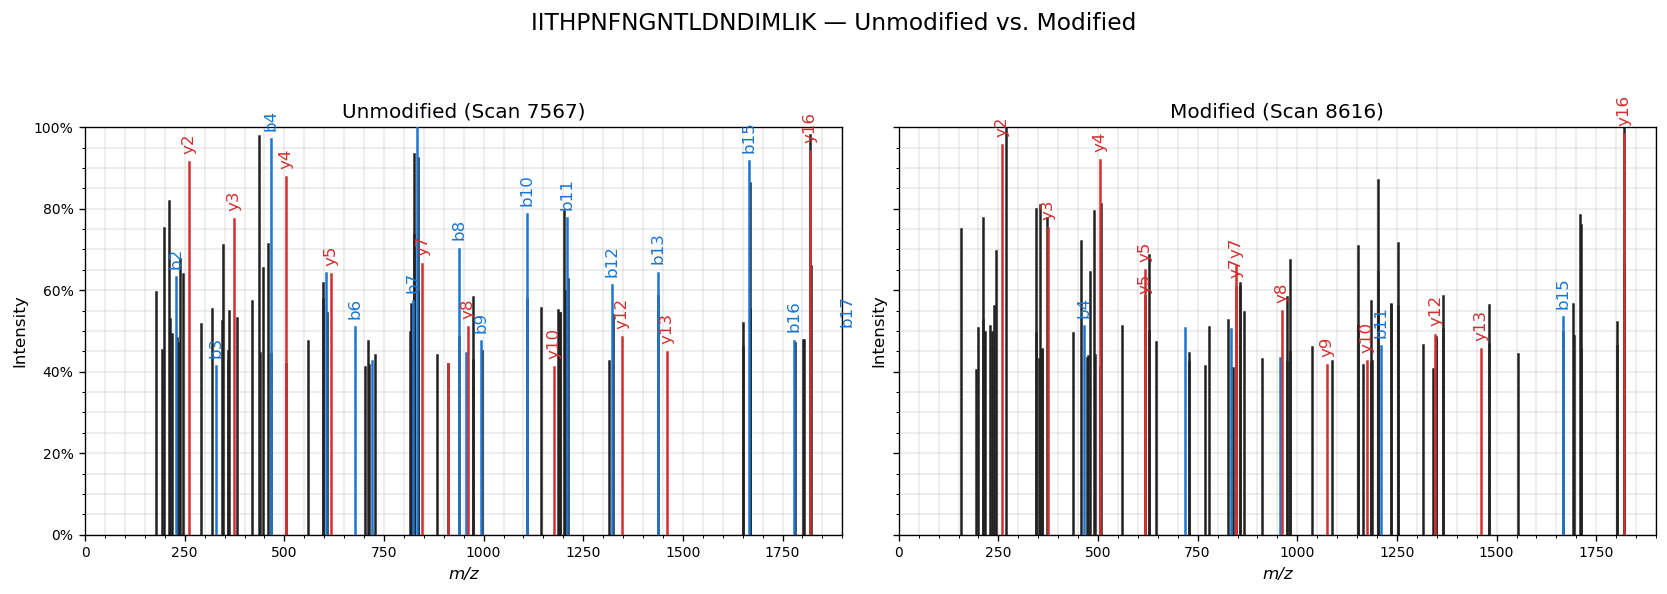

In [ ]:

seq = 'IITHPNFNGNTLDNDIMLIK'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 7567, peptide=seq)
spec_right = get_MS2_object(mzml_path, 8616, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = unmodified = scan 7567
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 7567)")

# Right panel = modified = scan 8616
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8616)")

fig.suptitle("IITHPNFNGNTLDNDIMLIK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

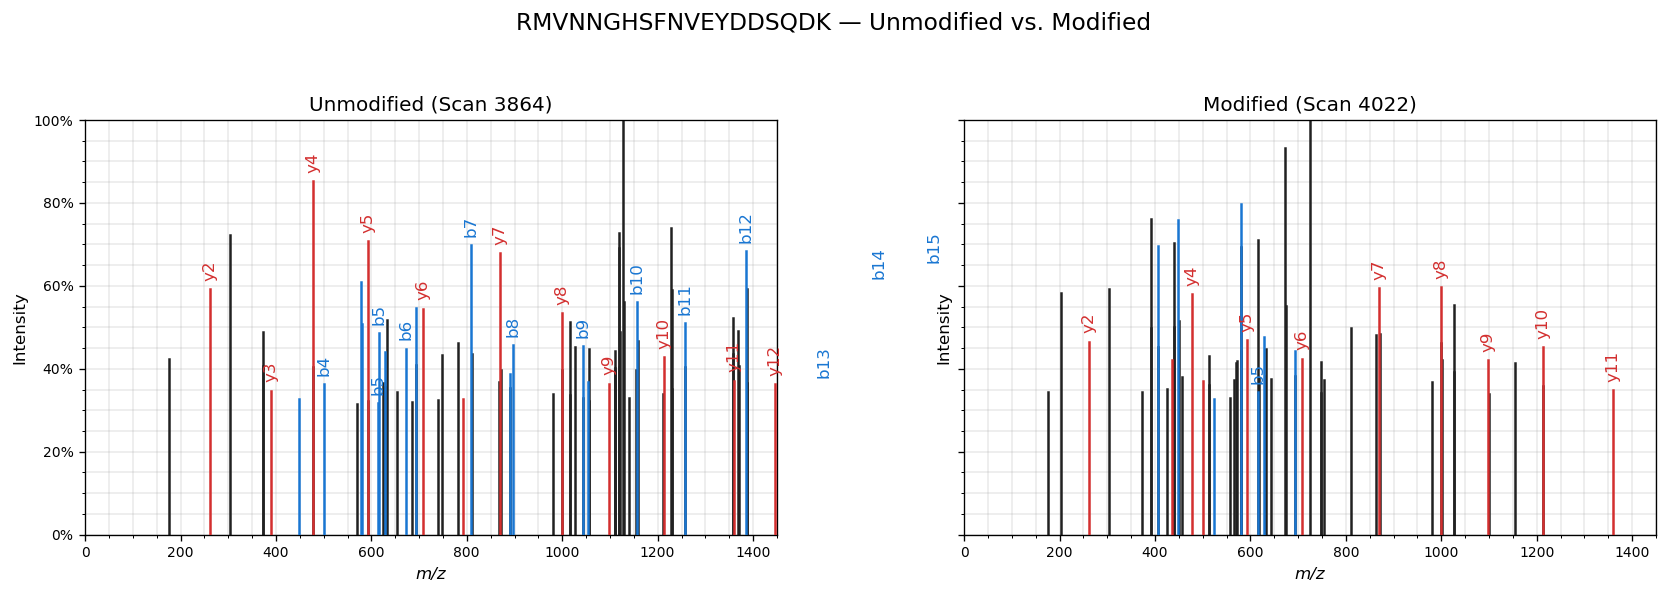

In [193]:

seq = 'RMVNNGHSFNVEYDDSQDK'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 3864, peptide=seq)
spec_right = get_MS2_object(mzml_path, 4022, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = unmodified = scan 3864
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 3864)")

# Right panel = modified = scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 4022)")

fig.suptitle("RMVNNGHSFNVEYDDSQDK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

There are two "trends" you might be noticing by now: <br></br>
1. Generally, when a spectrum (modified or unmodified) is annotated with the theoretical ion ladder for it's associated peptide, there is a significant proportion of that spectrum's intensity that is accounted for by the ion ladder.
2. Unmodified spectra better "match" or are better "accounted for" by the peptide's theoretical ion ladder than modified spectra. But there is not a significant difference.
<br></br>
But what if we were to use the ion ladder of one peptide to annotate the spectrum of a different peptide? Let's try using the theoretical ion ladder of AVVQDPALKPLALVYGEATSR to annotate the spectrum of a modified RMVNNGHSFNVEYDDSQDK peptide. We'll plot that on the right panel. On the left, we'll plot the spectrum of a modified AVVQDPALKPLALVYGEATSR spectrum and annotate it with the AVVQDPALKPLALVYGEATSR ion ladder (just as we did above). In this case, we are plotting spectra from **2 different peptides** and annotating them with **1 ion ladder.**

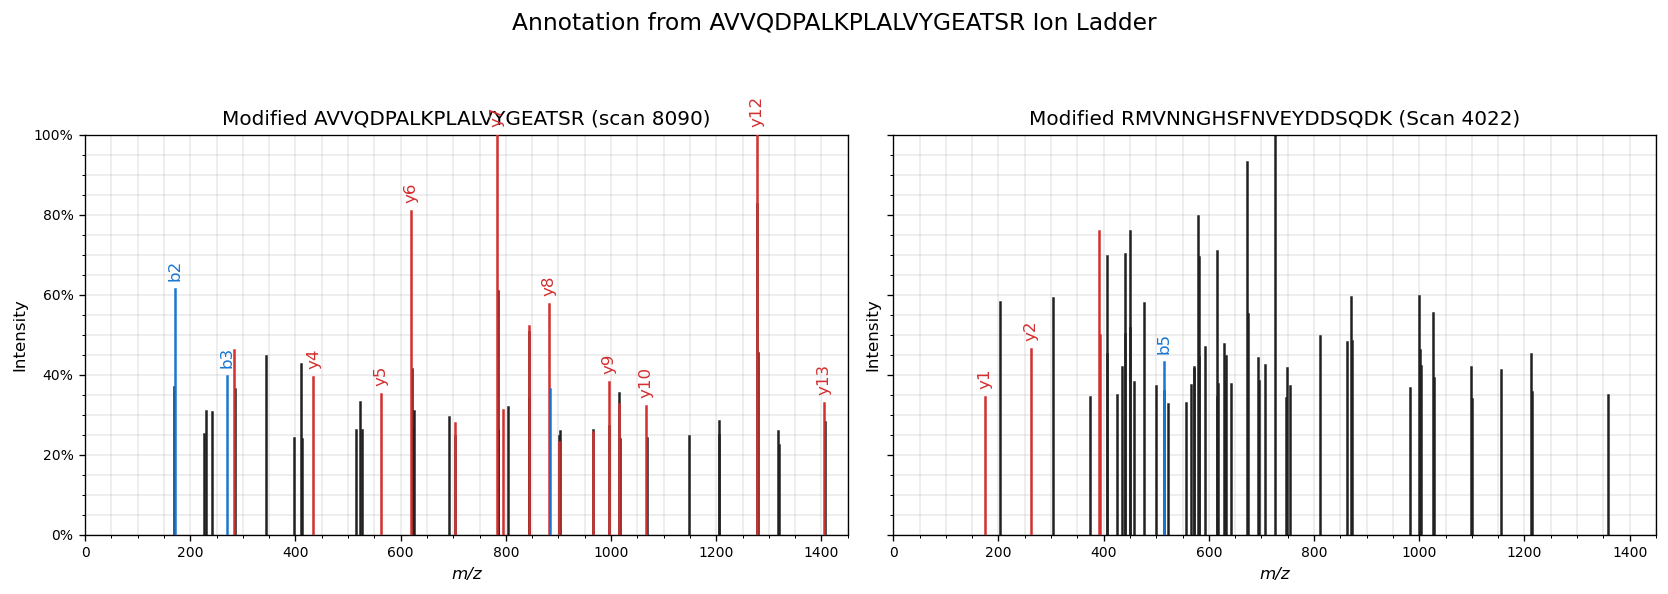

In [198]:
seq = 'AVVQDPALKPLALVYGEATSR'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 8090, peptide=seq)
spec_right = get_MS2_object(mzml_path, 4022, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = modified AVVQDPALKPLALVYGEATSR = scan 8090
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Modified AVVQDPALKPLALVYGEATSR (scan 8090)")

# Right panel = modified RMVNNGHSFNVEYDDSQDK = scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified RMVNNGHSFNVEYDDSQDK (Scan 4022)")

fig.suptitle("Annotation from AVVQDPALKPLALVYGEATSR Ion Ladder", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Let's do that once more, but this time annotating the spectrum of the modified RMVNNGHSFNVEYDDSQDK peptide using the theoretical ion ladder of RMVNNGHSFNVEYDDSQDK (on the left) and AVVQDPALKPLALVYGEATSR (on the right). In this case, we are plotting **1 spectrum** and annotating it with **2 different ion ladders.**

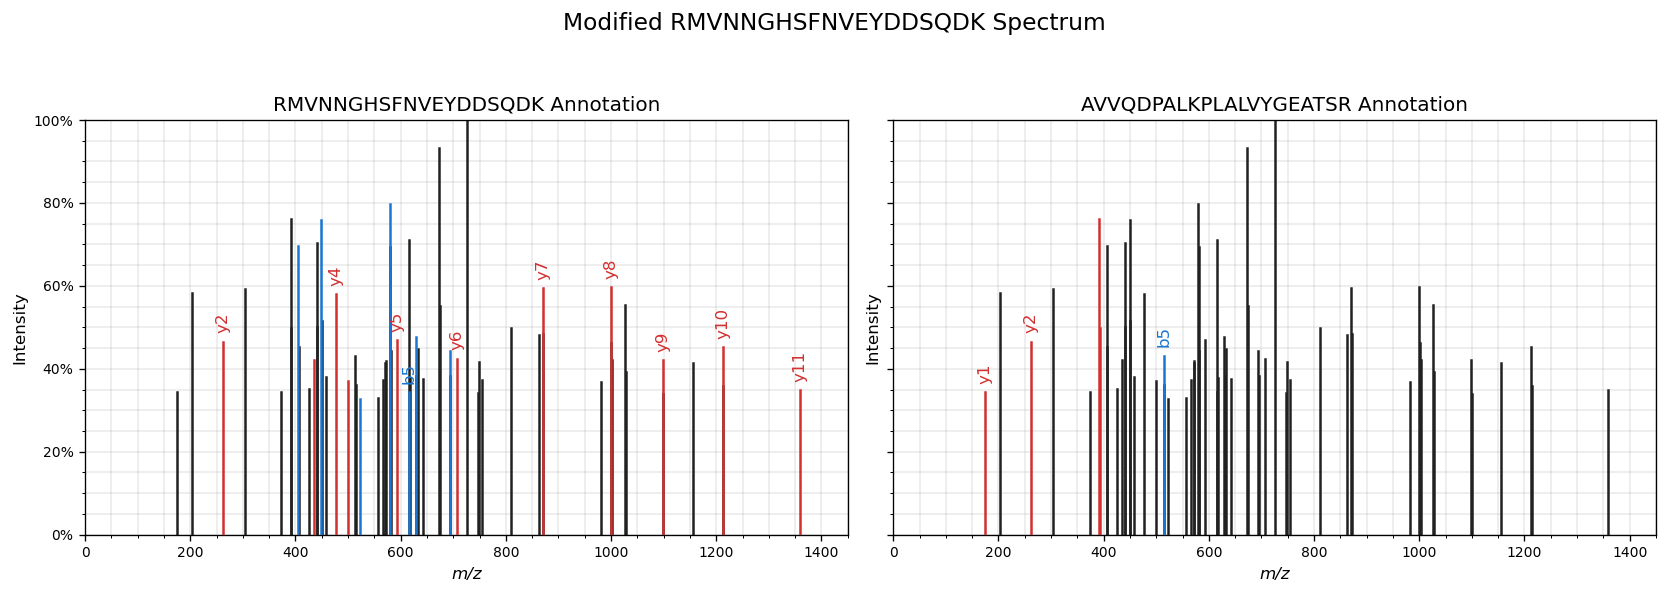

In [199]:
seq_1= 'RMVNNGHSFNVEYDDSQDK'
seq_2 = 'AVVQDPALKPLALVYGEATSR'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 4022, peptide=seq_1)
spec_right = get_MS2_object(mzml_path, 4022, peptide=seq_2)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = RMVNNGHSFNVEYDDSQDK Annotation, Scan 4022
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("RMVNNGHSFNVEYDDSQDK Annotation")

# Right panel = AVVQDPALKPLALVYGEATSR Annotation, scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("AVVQDPALKPLALVYGEATSR Annotation")

fig.suptitle("Modified RMVNNGHSFNVEYDDSQDK Spectrum", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Now, you're probably beginning to notice more meaningful trends. In the first example, where we annotated two different spectra (from different peptides) with the same ion ladder, a much greater proportion of the "matching" spectrum's intensity was accounted for by the ion ladder than of the other spectrum's intensity. In the second example, where we annotated the same spectrum using two different ion ladders (one belonging to the same peptide, and one not), a much greater proportion of the spectrum (annotated by it's associated peptide)'s intensity was accounted for by the ion ladder than of the spectrum (annoted by the other peptide)'s intensity.

## 3. Method 2: Positional Embedding of Peaks

### 3.1 Motivation

* Required Reading: https://www.nature.com/articles/s41467-024-49731-x
* Simple hashing and binning ignore relative *m/z* spacing.
* Many deep learning models require dense, continuous representations.

### 3.2 Encoding Strategy

* Apply **sinusoidal positional encoding** to each peak’s *m/z* value.
* Each peak is mapped to a **512-dimensional vector**.
* Intensities can be incorporated as additional features or scaling factors.

### 3.3 Applications

* Captures fine-grained relationships between peaks.
* Useful as input to transformer or deep learning architectures for spectral analysis.

## 4. Method 3: Positional Embedding of Augmented Spectra

### 4.1 Motivation

* Required Reading: https://www.nature.com/articles/s41592-025-02718-y
* Relevant signal spans multiple spectra: across retention time (RT) and between MS1 and MS2 levels.
* A richer representation is needed to capture this context.

### 4.2 2D Positional Encoding

* Represent each peak as a tuple: (*m/z*, intensity, RT offset, MS level).
* Apply **2D sinusoidal embeddings** to jointly encode *m/z* and RT.
* Concatenate with learned embeddings for intensity and spectrum level.
* Output: a **512-dimensional embedding** for each peak in the augmented spectrum.





![Each m/z value, m_j, is projected into 512 dimensions](CasanovoEncoding.png)

Positional encoding, as outlined in the Casanovo paper. D = 512

In [173]:
# Define positional encoding function used by Casanovo
# This function takes in 1 m/z value and returns a 512-dimensional positional encoding vector
# (this feels sort of like a reverse Fourier transform)
def positional_encoding(m_z, d_model = 512, lambda_min = 0.001, lambda_max = 10000):
    encoding = np.zeros(d_model)
    d_sin = int(d_model/2)
    d_cos = d_model - d_sin
    for d in range(d_sin):
        encoding[d] = np.sin(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**(d/(d_sin - 1))))
    for d in range(d_sin, d_model):
        encoding[d] = np.cos(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**((d - d_sin ) / (d_cos - 1))))
    return encoding


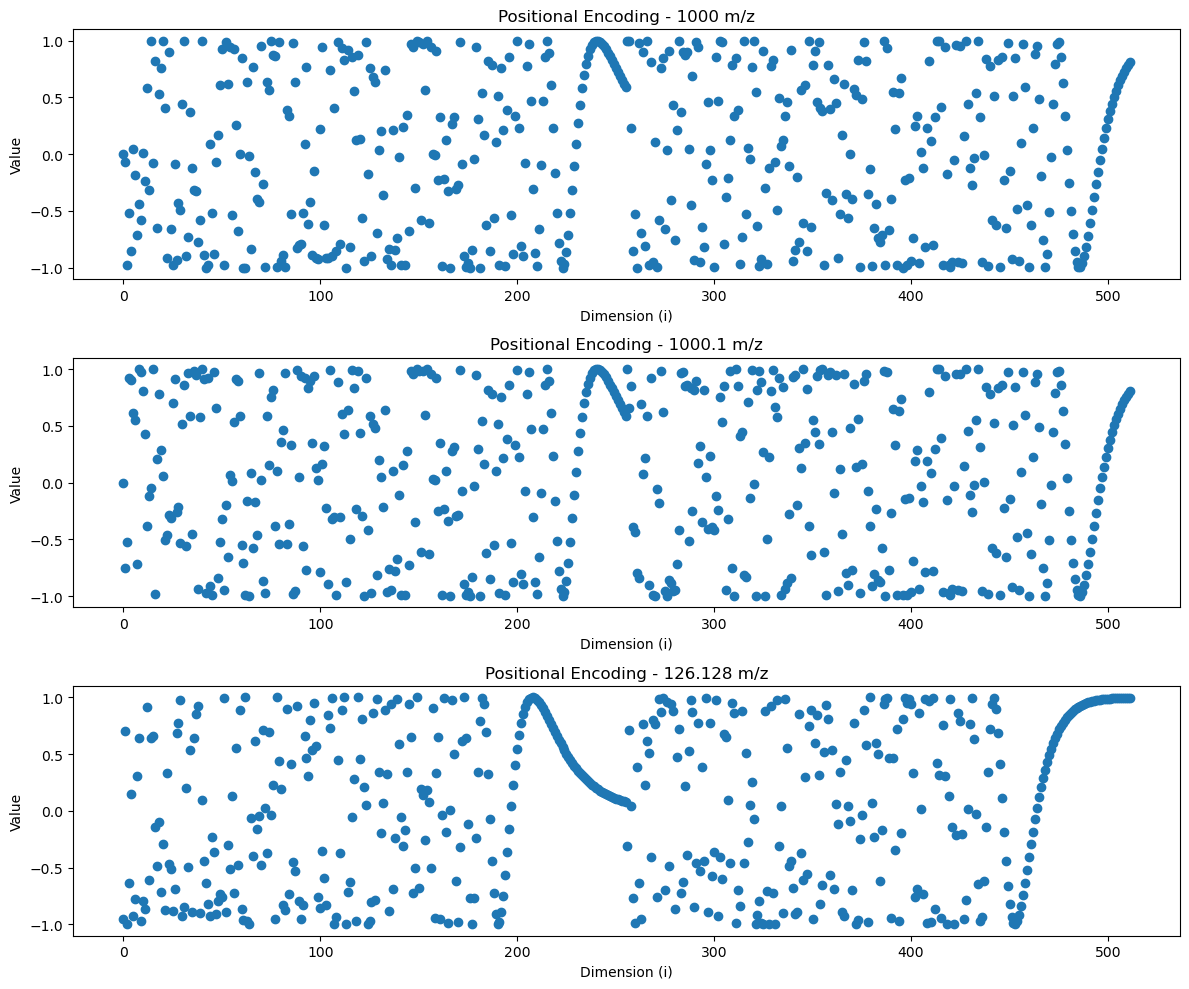

In [174]:
encode_1 = positional_encoding(1000)
encode_2 = positional_encoding(1000.1)
encode_3 = positional_encoding(126.1277)
# plot the encodings as three scatter plots,

# Set the figure size before creating subplots
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.scatter(range(len(encode_1)), encode_1)
plt.title("Positional Encoding - 1000 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.scatter(range(len(encode_2)), encode_2)
plt.title("Positional Encoding - 1000.1 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 3)
plt.scatter(range(len(encode_3)), encode_3)
plt.title("Positional Encoding - 126.128 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()


I only halfway understand what's going on here, so the following explanation should be taken with a grain of salt

The positional encoding attempts to capture both high-resolution information and low-resolution information.

Dimensions ~200-255 and ~450-500 capture low resolution information. They will only differ if there is a large m/z difference between the encoded values.

Dimensions 0-50 and 256-300 encoded high resolution information. They change even if the m/z values are very close together

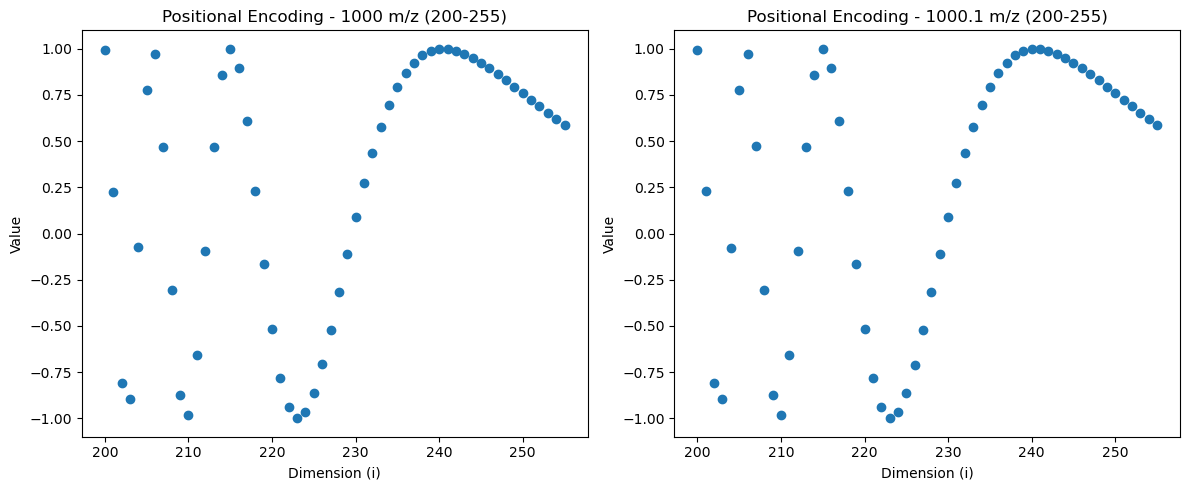

Cosine Similarity (1000 m/z vs 1000.1 m/z): 0.9999997415834383


In [175]:
# for encode_1 and encode_2, plot the values from 200 to 255
# and calculate the cosine similarity between the two
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(200, 256), encode_1[200:256])
plt.title("Positional Encoding - 1000 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(200, 256), encode_2[200:256])
plt.title("Positional Encoding - 1000.1 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[200:256]], [encode_2[200:256]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])

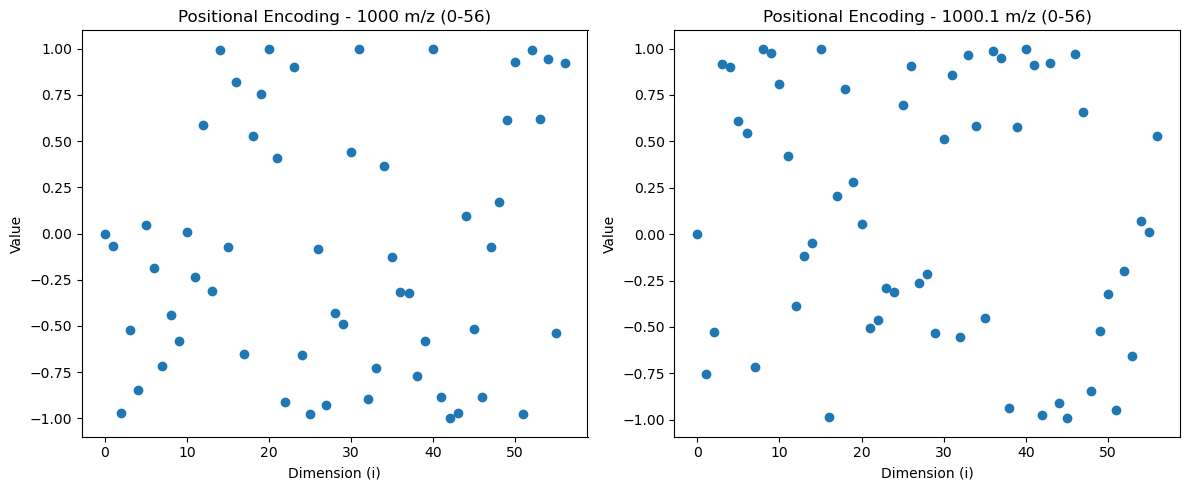

Cosine Similarity (1000 m/z vs 1000.1 m/z): -0.04100383952610734


In [176]:
# Repeat the above plots and calculations, but this time only consider the range from 0 to 56
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(0, 57), encode_1[0:57])
plt.title("Positional Encoding - 1000 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(0, 57), encode_2[0:57])
plt.title("Positional Encoding - 1000.1 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[0:57]], [encode_2[0:57]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])